# Esame Laboratorio di Programmazione II - 27/06/2025


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
import plotly.graph_objects as go
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split

## Esercizio 1

Crea un array NumPy con i prezzi (in euro) di 5 libri: **14.99, 22.50, 9.75, 18.00, 31.20, 12.80, 24.90, 8.40, 19.99, 27.30**

1. Calcola il prezzo medio dei libri
2. Seleziona i libri con un prezzo maggiore della media.
3. Crea un nuovo array che applica uno sconto del 10% solo ai libri che costano più della media.

In [17]:
prezzi = np.array([14.99, 22.50, 9.75, 18.00, 31.20, 12.80, 24.90, 8.40, 19.99, 27.30])
media = prezzi.mean()
libri_maggiori_media = prezzi[prezzi > media]
new_array = np.where((prezzi>media), prezzi*0.9, prezzi)

print(f"Prezzi: {prezzi} \nMedia: {media} \nLibri con prezzo maggiore della media: {libri_maggiori_media}\nNuovo array con sconto del 10%: {new_array}")

Prezzi: [14.99 22.5   9.75 18.   31.2  12.8  24.9   8.4  19.99 27.3 ] 
Media: 18.983000000000004 
Libri con prezzo maggiore della media: [22.5  31.2  24.9  19.99 27.3 ]
Nuovo array con sconto del 10%: [14.99  20.25   9.75  18.    28.08  12.8   22.41   8.4   17.991 24.57 ]


## Esercizio 2

Simula 1000 lanci di una moneta che ad ogni lancio ha il doppio di probabilità di risultare croce invece che testa. Ogni lancio è rappresentato da 1 (testa) o 0 (croce).

1. Crea un array NumPy contenente i risultati.
2. Calcola la proporzione di teste dopo ogni 50 lanci cumulativi.
3. Crea un grafico della proporzione cumulativa nel tempo (dopo 50 lanci, dopo 100, dopo 150,...).

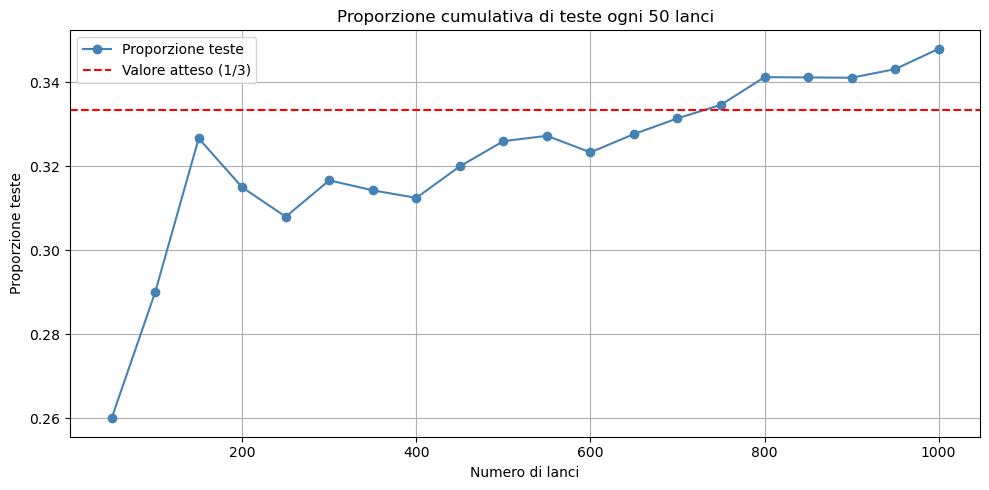

In [19]:
# 1
lanci = np.random.choice([0,1], size = 1000, p = [2/3, 1/3])

# 2
intervalli = np.arange(50, 1001, 50)
proporzioni = [np.mean(lanci[:i]) for i in intervalli]

# 3
plt.figure(figsize=(10, 5))
plt.plot(intervalli, proporzioni, marker='o', color='steelblue', label='Proporzione teste')
plt.axhline(y=1/3, color='red', linestyle='--', label='Valore atteso (1/3)')
plt.title('Proporzione cumulativa di teste ogni 50 lanci')
plt.xlabel('Numero di lanci')
plt.ylabel('Proporzione teste')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Esercizio 3

Crea una funzione di nome **mat_normalizzata** che prende come input una matrice e ritorna la matrice normalizzata.

La funzione deve quindi:
1. Calcolare la media e la deviazione standard della matrice.
2. Normalizzare la matrice sottraendo la media e dividendo per la deviazione standard.

Testa La funzione con un array NumPy 6x10 con numeri campionati da una distribuzione normale (media=5, std=2).

In [20]:
def mat_normalizzata(matrice):
    media = np.mean(matrice)
    std = np.std(matrice)
    return (matrice - media)/std

matrice = np.random.normal(loc=5, scale=2, size=(6,10))

print("Matrice originale:")
print(matrice.round(2))
print(f"\nMedia: {np.mean(matrice):.4f}, Std: {np.std(matrice):.4f}")

risultato = mat_normalizzata(matrice)

print("\nMatrice normalizzata:")
print(risultato.round(2))
print(f"\nMedia: {np.mean(risultato):.4f}, Std: {np.std(risultato):.4f}")

Matrice originale:
[[ 7.52  4.55  4.91  4.42  6.63  6.33  5.91  5.26  3.73  5.96]
 [ 1.85  2.21  3.    3.8   1.39  7.32  5.21  6.89  5.2   6.76]
 [ 3.27  6.54  9.68  4.87  4.77  7.28  7.31  4.16  6.63  1.89]
 [ 4.05  2.47  4.91 10.29  6.97  8.14  4.43  5.74  3.11  1.38]
 [ 7.38  5.81  8.78  4.53  6.88  8.44  8.6   5.68  3.85  8.07]
 [ 7.41  5.62  3.7   7.22  6.15  5.64  8.63  4.17  1.67  3.71]]

Media: 5.4780, Std: 2.1146

Matrice normalizzata:
[[ 0.97 -0.44 -0.27 -0.5   0.54  0.4   0.2  -0.1  -0.83  0.23]
 [-1.72 -1.54 -1.17 -0.79 -1.93  0.87 -0.13  0.67 -0.13  0.61]
 [-1.04  0.5   1.99 -0.29 -0.34  0.85  0.86 -0.62  0.54 -1.69]
 [-0.67 -1.42 -0.27  2.28  0.71  1.26 -0.5   0.13 -1.12 -1.94]
 [ 0.9   0.16  1.56 -0.45  0.66  1.4   1.48  0.09 -0.77  1.22]
 [ 0.91  0.07 -0.84  0.82  0.32  0.08  1.49 -0.62 -1.8  -0.83]]

Media: 0.0000, Std: 1.0000


## Esercizio 4

Utilizza il dataset `books.csv`.

1. **Crea una nuova colonna** chiamata `engagement_score`, definita come:

   $$
   \texttt{engagement\_score} = \texttt{average\_rating} \times \log_{10}(1 + \texttt{ratings\_count})
   $$

   *(Un indicatore che tiene conto sia della qualità (valutazione media), sia della quantità di voti. Il logaritmo serve ad attenuare l'effetto dei libri estremamente popolari.)*

2. Trova il **libro con il valore massimo** di `engagement_score`.

3. **Filtra i libri** con una valutazione media (`average_rating`) **maggiore di 4.5**.

4. **Crea un grafico a barre** con i 10 libri con il valore più alto di `engagement_score`.

5. **Crea un grafico a linee** della `average_rating`, ordinando i libri per `ratings_count` crescente.


Valore massimo di engagement_score: 18.468549131028


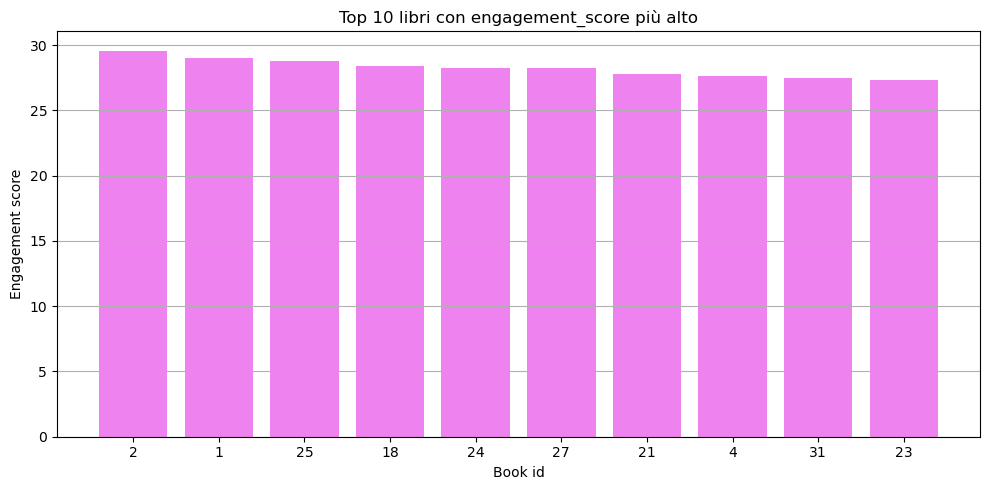

In [2]:
df = pd.read_csv('books.csv')

# 1
df['engagement_score'] = df['average_rating']*np.log10(1 + df['ratings_count'])

# 2
print(f"Valore massimo di engagement_score: {df['engagement_score'].value_counts().idxmax()}")

# 3
df_filtrato = df[df['average_rating'] > 4.5]

# 4
top10 = df.nlargest(10, 'engagement_score')

plt.figure(figsize=(10,5))
plt.bar(top10['book_id'].astype(str), top10['engagement_score'], color='violet')
plt.title('Top 10 libri con engagement_score più alto')
plt.xlabel('Book id')
plt.ylabel('Engagement score')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

# 5 

## Esercizio 5
Utilizza il dataset `adult.csv`.
Contiene informazioni demografiche su adulti negli Stati Uniti. Le colonne rilevanti sono:
- `age`: età (integer)
- `workclass`, `education`, `marital-status`, `occupation`, `race`, `sex`
- `hours-per-week`: ore lavorate a settimana
- `income`: `>50K` o `<=50K` (target)

1. Quante **righe e colonne** ha il dataset?
2. Quanti **valori mancanti** ci sono per colonna?
3. **Sostituisci i valori mancanti** nelle colonne categoriche (workclass, occupation, native-country) con il valore più frequente (la moda).
4. Calcola l’**età media** (`age`) per sesso (`sex`)
5. Trova la % di persone che guadagnano **>50K** per sesso.
7. Crea una **colonna `age_group`** raggruppando le età in fasce: `'<30'`, `'30-50'`, `'>50'`.
8. **Crea**:
   - un grafico **a barre** con % di reddito `>50K` per fascia di età.
   - un **boxplot** delle ore lavorate (`hours-per-week`) per gruppo reddito (<=50, >50).


Righe: 32561, Colonne: 15

Valori mancanti per colonna:
age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

Età media per sesso:
sex
Female    36.858230
Male      39.433547
Name: age, dtype: float64

% >50K per sesso:
sex
Female    10.946059
Male      30.573658
Name: income, dtype: float64


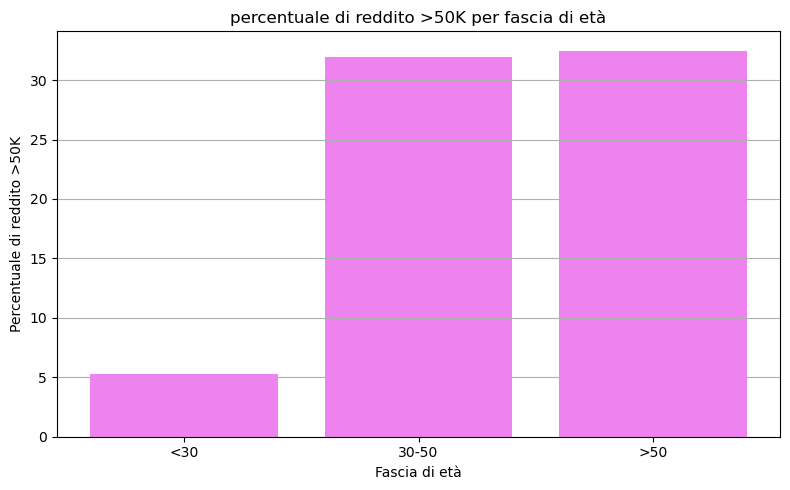

C:\Users\Viola\AppData\Local\Temp\ipykernel_12656\1353008148.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=gruppi)


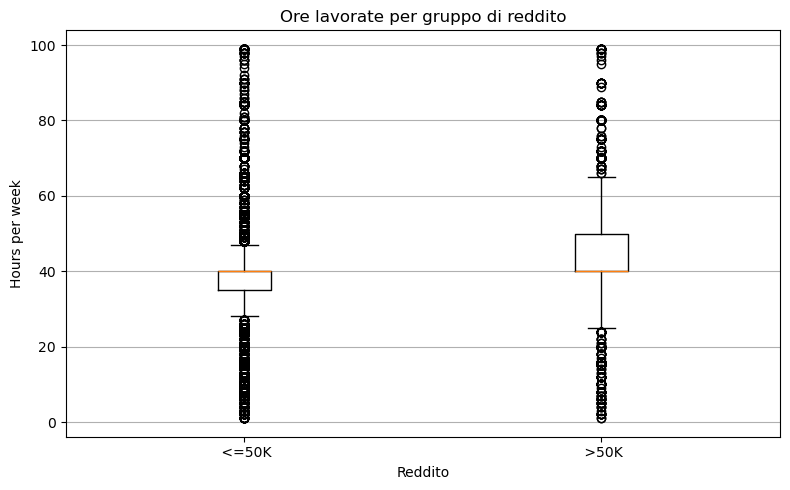

<ArrowStringArray>
[' <=50K', ' >50K']
Length: 2, dtype: str


In [5]:
df = pd.read_csv("adult_con_titoli.csv")

# 1
print(f"Righe: {df.shape[0]}, Colonne: {df.shape[1]}")

# 2
print(f"\nValori mancanti per colonna:\n{df.isnull().sum()}")

# 3
for col in ['workclass', 'occupation', 'native-country']:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])

# 4
print(f"\nEtà media per sesso:\n{df.groupby('sex')['age'].mean()}")

# 5
perc_50k = df.groupby('sex')['income'].apply(lambda x: (x == ' >50K').mean() * 100)
print(f"\n% >50K per sesso:\n{perc_50k}")

# 6
df['age_group'] = pd.cut(
    df['age'],
    bins = [0, 29, 50, float('inf')],
    labels=['<30', '30-50', '>50']
)

# 7a
perc_age = df.groupby('age_group')['income'].apply(lambda x: (x == ' >50K').mean() * 100)
plt.figure(figsize = (8,5))
plt.bar(perc_age.index, perc_age.values, color='violet')
plt.title('percentuale di reddito >50K per fascia di età')
plt.xlabel('Fascia di età')
plt.ylabel('Percentuale di reddito >50K')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

# 7b
gruppi = [' <=50K', ' >50K']
data = [df[df['income'] == g]['hours-per-week'].dropna().values for g in gruppi]
plt.figure(figsize=(8,5))
plt.boxplot(data, labels=gruppi)
plt.title('Ore lavorate per gruppo di reddito')
plt.xlabel('Reddito')
plt.ylabel('Hours per week')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

print(df['income'].unique())

## Esercizio 6

Genera due array:

`x = np.linspace(0, 5, 80)`  
`y = 2.5 * x + 1.2 + np.random.normal(0, 0.5, 80)`

1. Usa `scipy.optimize.curve_fit` per stimare i parametri della retta.
2. Plotta i punti originali e la retta ottenuta.
3. Calcola MAE e RMSE tra i valori reali e quelli stimati.

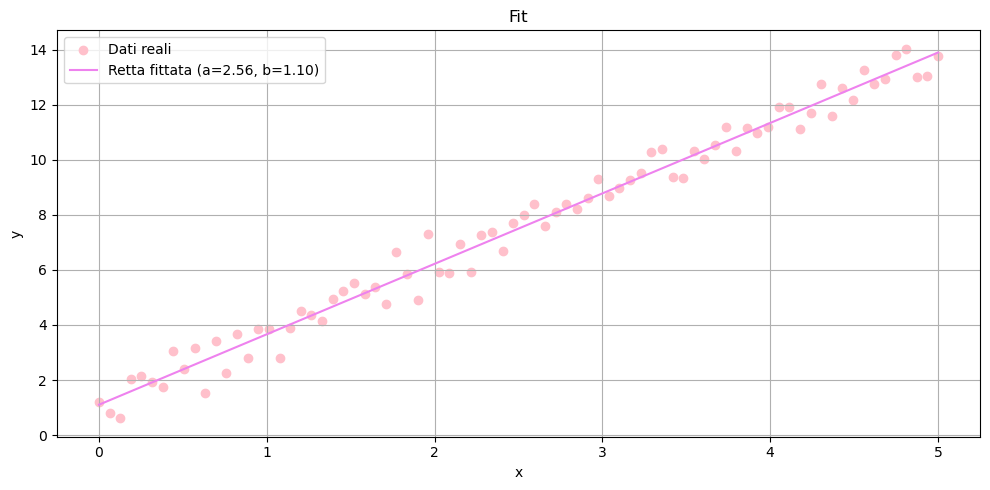

MAE: 0.4140
RMSE: 0.5062


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

x = np.linspace(0,5,80)
y = 2.5 * x + 1.2 + np.random.normal(0, 0.5, 80)

# 1
def retta(x, a, b):
    return a*x + b

params, cov = curve_fit(retta,x,y)
a,b = params

y_fit = retta(x,a,b)

# 2
plt.figure(figsize=(10,5))
plt.scatter(x, y, color='pink', label='Dati reali')
plt.plot(x, y_fit, color='violet', label=f'Retta fittata (a={a:.2f}, b={b:.2f})')
plt.title('Fit')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 3
MAE = np.mean(np.abs(y-y_fit))
RMSE = np.sqrt(np.mean((y-y_fit)**2))

print(f"MAE: {MAE:.4f}\nRMSE: {RMSE:.4f}")